# 📉 PCA (Principal Component Analysis)

## 🎯 Objective

- Reduce dimensionality of data  
- Preserve maximum variance  
- Visualize high-dimensional data  

---

## 🧠 Key Idea

> Transform features into new axes (principal components) where variance is maximum

In [1]:
# Import required libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

## 📊 Load Dataset

We will use the **Iris dataset** for PCA demonstration.

In [2]:
# Load dataset
data = load_iris()

X = data.data
y = data.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Check shape
print("Shape:", df.shape)

# Check null values
print("\nNull values:\n", df.isnull().sum())

Shape: (150, 5)

Null values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


## ⚙️ Feature Scaling

PCA is sensitive to scale → we must standardize data

In [4]:
# Separate features
X = df.drop('target', axis=1)

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check mean & variance
print("Mean:", X_scaled.mean())
print("Std:", X_scaled.std())

Mean: -4.855375361027351e-16
Std: 1.0


## 📉 Apply PCA

We reduce dimensions from 4 → 2

In [5]:
# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y

pca_df.head()

,PC1,PC2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


## 📊 Explained Variance

Shows how much information each component retains

In [6]:
# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Total variance retained
print("Total Variance:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance: 0.9581320720000166


## 📈 Visualization

Plot PCA components

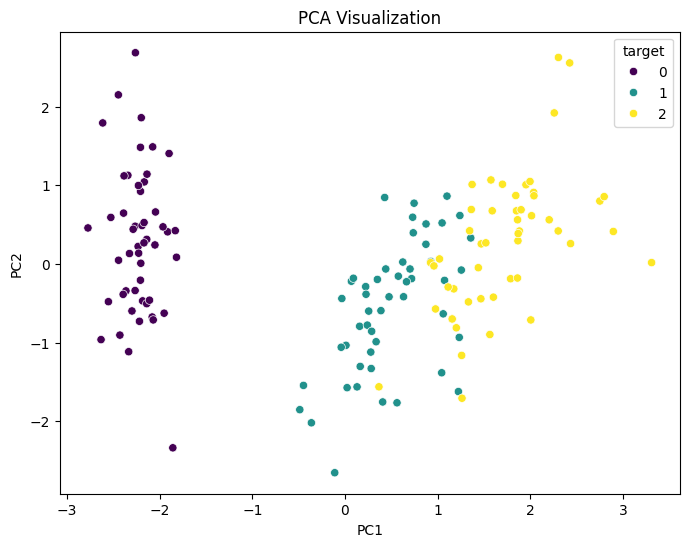

In [7]:
# Scatter plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='target',
    palette='viridis',
    data=pca_df
)

plt.title("PCA Visualization")
plt.show()

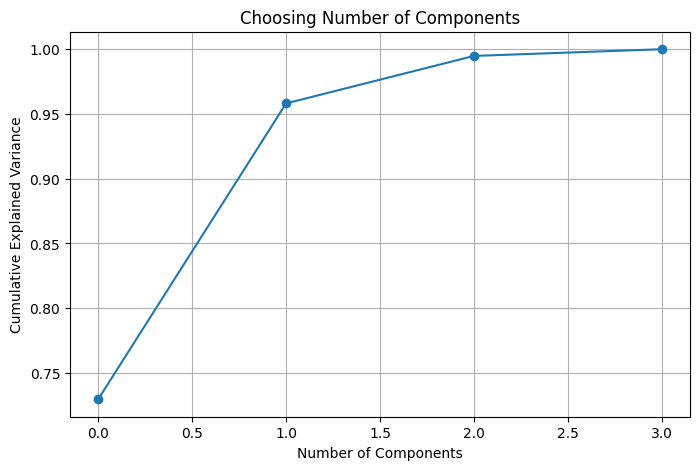

In [8]:
# PCA with all components
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Plot cumulative variance
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Choosing Number of Components")
plt.grid()
plt.show()

## ✅ Conclusion

- PCA reduces dimensions while preserving variance  
- First few components capture most information  
- Useful for visualization and noise reduction  

---

## 🧠 Key Takeaways

- Always scale data before PCA  
- Use explained variance to choose components  
- PCA helps in faster training  

---

## 🧠 One-Line Summary

> PCA reduces dimensionality by projecting data onto directions of maximum variance